In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.morphology import h_minima

In [ ]:
tif_path = r"R_24FZ2.TIF"

with rasterio.open(tif_path) as src:
    elevation = src.read(1, masked=True).astype(float)
    elevation = elevation.filled(np.nan) #filling masked values with NaN
    elevation[~np.isfinite(elevation)] = np.nan
    elevation[elevation > 1e30] = np.nan

    print("Array shape:", elevation.shape)
    print("Height / rows:", src.height)
    print("Width / columns:", src.width)
    print("Number of bands:", src.count)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)
    print("CRS:", src.crs)

print("Min:", np.nanmin(elevation))
print("Max:", np.nanmax(elevation))
print("Mean:", np.nanmean(elevation))
print("Total number of pixels:", elevation.size)

Array shape: (12500, 10000)
Height / rows: 12500
Width / columns: 10000
Number of bands: 1
Resolution: (0.5, 0.5)
Bounds: BoundingBox(left=95000.0, bottom=487500.0, right=100000.0, top=493750.0)
CRS: EPSG:28992
Min: -1.3370000123977661
Max: 78.72429656982422
Mean: 7.893062394913911
Total number of pixels: 125000000


In [ ]:
interval_size = 10 #elevation intervals
intervals = np.arange(-10, 90 + interval_size, interval_size) 

valid = elevation[np.isfinite(elevation)]
hist, bin_edges = np.histogram(valid, bins=intervals)

print("Elevation intervals:")
for i in range(len(hist)):
    if hist[i] > 0:
        print(f"Interval {intervals[i]} - {intervals[i+1]}: {hist[i]} pixels")

Elevation intervals:
Interval -10 - 0: 802803 pixels
Interval 0 - 10: 46442894 pixels
Interval 10 - 20: 16604166 pixels
Interval 20 - 30: 1737824 pixels
Interval 30 - 40: 168169 pixels
Interval 40 - 50: 10395 pixels
Interval 50 - 60: 1499 pixels
Interval 60 - 70: 52 pixels
Interval 70 - 80: 2556 pixels


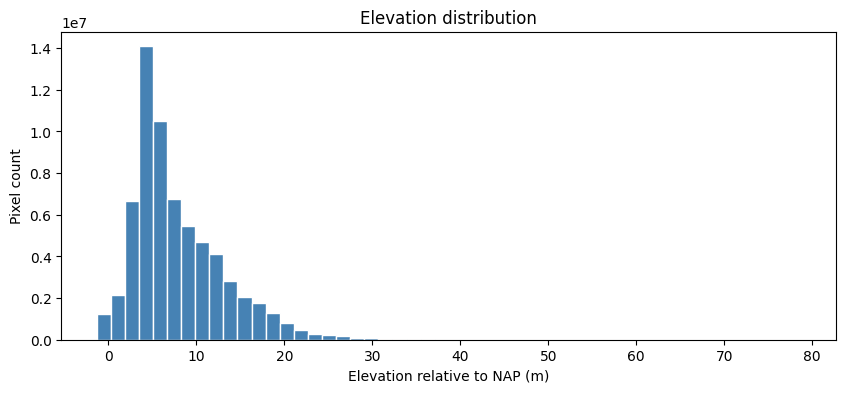

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(valid, bins=50, color="steelblue", edgecolor="white")
plt.title("Elevation distribution")
plt.xlabel("Elevation relative to NAP (m)")
plt.ylabel("Pixel count")
plt.show() #distribution of elevation values in the whole tif file data.

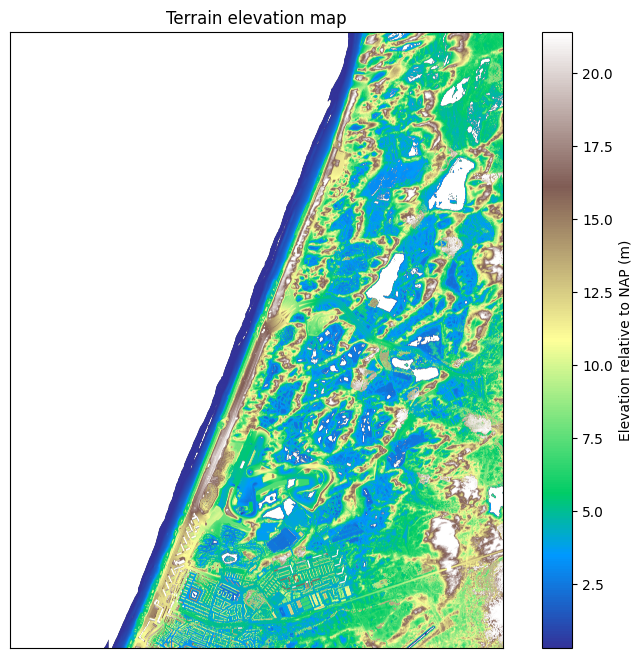

In [ ]:
plt.figure(figsize=(10, 8)) #visualization of the elevation data as a terrain map.
vmin, vmax = np.nanpercentile(elevation, [2, 98])

plt.imshow(elevation, cmap="terrain", vmin=vmin, vmax=vmax)
plt.colorbar(label="Elevation relative to NAP (m)")
plt.title("Terrain elevation map")
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
#cropping region of the elevation data for limited memory usage and faster processing.
row_start, row_end = 9500, 13000 #vertical range of crop
col_start, col_end = 4000, 7000 #horizontal range of crop

crop = elevation[row_start:row_end, col_start:col_end]

print("Crop shape:", crop.shape) #3000x3000 is okay, ~5000x5000 starts to take a long time
print("Crop min:", np.nanmin(crop))
print("Crop max:", np.nanmax(crop))
print("Crop mean:", np.nanmean(crop))

Crop shape: (3000, 3000)
Crop min: 0.3736000061035156
Crop max: 51.59379959106445
Crop mean: 6.3268268605093825


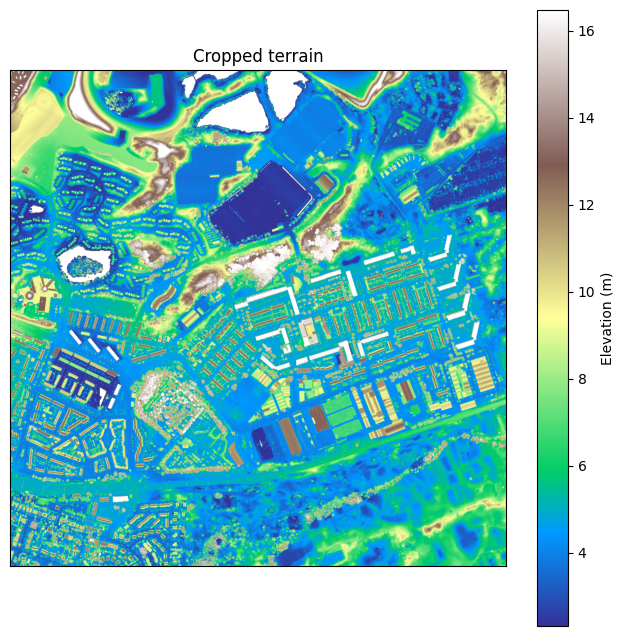

In [ ]:
plt.figure(figsize=(8, 8)) #visualization of the cropped elevation data as a terrain map.
vmin_crop, vmax_crop = np.nanpercentile(crop, [2, 98])

plt.imshow(crop, cmap="terrain", vmin=vmin_crop, vmax=vmax_crop)
plt.colorbar(label="Elevation (m)")
plt.title("Cropped terrain")
plt.xticks([])
plt.yticks([])
plt.show()

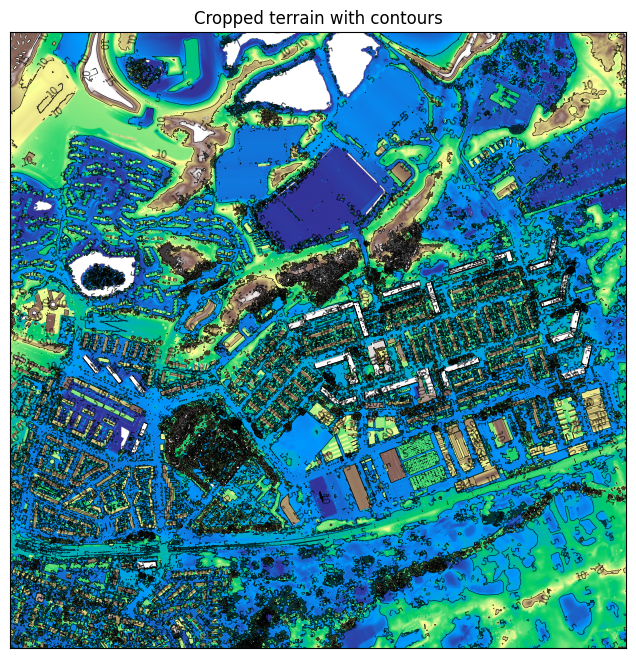

In [ ]:
plt.figure(figsize=(8, 8)) #visualization of the cropped elevation data as a terrain map with contours.
vmin_crop, vmax_crop = np.nanpercentile(crop, [2, 98])

plt.imshow(crop, cmap="terrain", vmin=vmin_crop, vmax=vmax_crop)
contours = plt.contour(crop, levels=10, colors="black", linewidths=0.5, alpha=0.7) #adding black contour lines to the terrain map (also shows trees well)
plt.clabel(contours, inline=True, fontsize=7)
plt.title("Cropped terrain with contours")
plt.xticks([])
plt.yticks([])
plt.show()

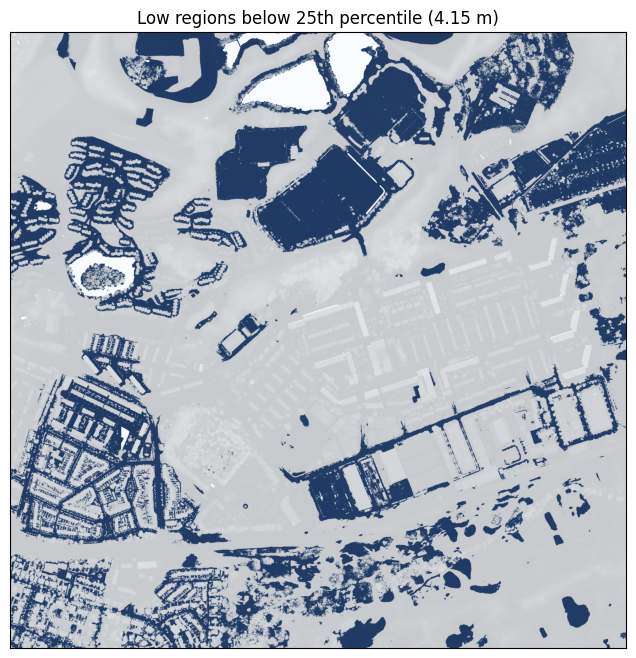

In [ ]:
low_threshold = np.nanpercentile(crop, 25) #is 25th percentile a good threshold for low elevation?
low_regions = (crop <= low_threshold)

plt.figure(figsize=(8, 8)) #visualization of the low elevation regions in the cropped area (below 25th percentile).
plt.imshow(crop, cmap="Greys_r", alpha=0.7)
plt.imshow(low_regions, cmap="Blues", alpha=0.7)
plt.title(f"Low regions below 25th percentile ({low_threshold:.2f} m)")
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
def find_local_minima_simple(Z): #finding local minima by comparing each pixel to its 4 neighbors (up, down, left, right)
    rows, cols = Z.shape
    minima = []

    for r in range(1, rows - 1): #ignoring borders to avoid out-of-bounds errors
        for c in range(1, cols - 1):
            val = Z[r, c] #current pixel value
            if not np.isfinite(val):
                continue #skip NaN values
            #check if current pixel is less than its 4 neighbors
            if (
                val < Z[r - 1, c]
                and val < Z[r + 1, c]
                and val < Z[r, c - 1]
                and val < Z[r, c + 1]
            ):
                minima.append((r, c, val))

    return np.array(minima, dtype=float) if minima else np.empty((0, 3))


def find_meaningful_minima(Z, sigma=1, h_threshold=0.5): #finding more meaningful local minima by smoothing the DEM and using h_minima to filter out shallow depressions.
    # 1. Smooth the DEM
    # sigma=1 is mild; higher values will smooth more but may also remove smaller features. Can experiment..
    crop_smooth = gaussian_filter(Z, sigma=sigma)
    
    # 2. Extract basins with depth >= h_threshold (in meters)
    #h_threshold = 0.5 ignores all depressions shallower than 0.5m, but can be experimented too..
    minima_mask = h_minima(crop_smooth, h=h_threshold)
    
    return np.argwhere(minima_mask)

In [ ]:
crop_filled = crop.copy()
crop_filled = np.nan_to_num(crop_filled, nan=np.nanmean(crop_filled))

#minima = find_local_minima_simple(crop_filled)
minima = find_meaningful_minima(crop_filled)
print(f"Found {len(minima)} local minima in crop")

Found 5219 local minima in crop


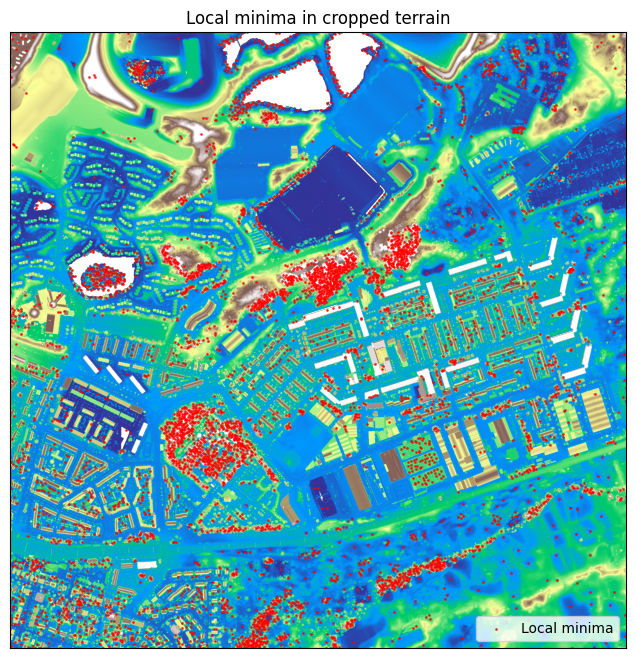

In [ ]:
plt.figure(figsize=(8, 8)) #visualization of the local minima on the cropped terrain map.
plt.imshow(crop, cmap="terrain", vmin=vmin_crop, vmax=vmax_crop)

if len(minima) > 0:
    plt.scatter(minima[:, 1], minima[:, 0], c="red", s=1, alpha=0.7, label="Local minima")
    plt.legend()

plt.title("Local minima in cropped terrain")
plt.xticks([])
plt.yticks([])
plt.show()

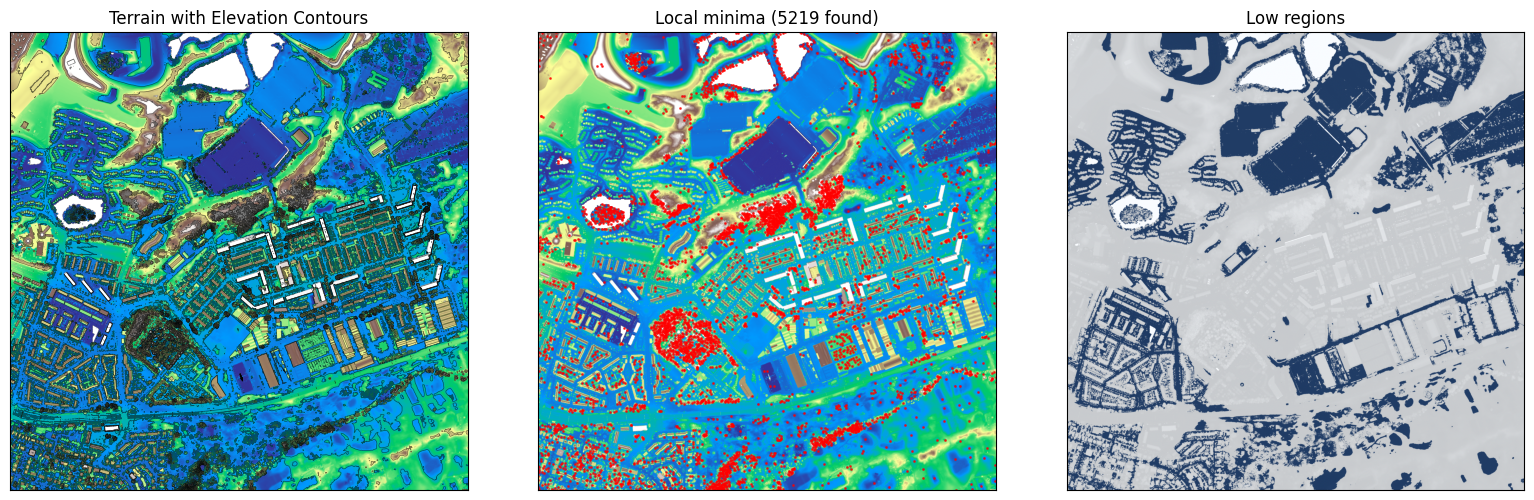

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#terrain with contours
axes[0].imshow(crop, cmap="terrain", vmin=vmin_crop, vmax=vmax_crop)
axes[0].contour(crop, levels=10, colors='black', linewidths=0.5, alpha=0.5)
axes[0].set_title("Terrain with Elevation Contours")

#Local Minima
axes[1].imshow(crop, cmap="terrain", vmin=vmin_crop, vmax=vmax_crop)
if len(minima) > 0:
    axes[1].scatter(minima[:, 1], minima[:, 0], c="red", s=1, alpha=0.7)
axes[1].set_title(f"Local minima ({len(minima)} found)")

#Low elevation regions
axes[2].imshow(crop, cmap="Greys_r", alpha=0.7)
axes[2].imshow(low_regions, cmap="Blues", alpha=0.7)
axes[2].set_title("Low regions")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()